## Benchmarking sur les différents modéles de RNN (BiLSTM, LSTM and GRU)

L'objectif de ce travail est  de faire une étude comparative des différentes variètés de RNN qui sont: BiLSTM, LSTM

et GRU. Il s'agit de tester les performances de chaque modéle grâce aux métriques sur les erreurs de prévisions.  

Afin de selectionner pour la prochaine étape, la meilleur architecture de RNN capable de prédire avec plus 

précision les précipitations.

## Import libraries

In [1]:
import scipy
import numpy
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers, callbacks
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt
from IPython.core.pylabtools import figsize

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import seaborn as sns
#plt.style.use('seaborn')

2025-09-29 18:43:18.795015: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-29 18:43:18.863780: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-29 18:43:20.865865: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Set random seed for reproducibility
np.random.seed(1705)
tf.random.set_seed(1234)

In [ ]:
# Read and explore data 
## chargement de la data initiale
dataset = pd.read_csv("/home/oem/Documents/these/code/test_timGAN3/data.csv", index_col="time", parse_dates=["time"])
print(dataset.shape)

In [ ]:
dataset

In [1]:
# Read and explore data 
## chargement de l'echantillon
dataset = pd.read_csv('sample_test.csv', index_col="time", parse_dates=["time"])
print(dataset.shape)

NameError: name 'pd' is not defined

In [2]:
dataset= dataset.fillna(0)
dataset.head()

NameError: name 'dataset' is not defined

In [3]:
# Data description
generated_data.describe()

NameError: name 'generated_data' is not defined

## Echantillonnage aléatoire de la base de données initiales

Vue la puissance de calcul trés faible à ma disposition, car mon laptop ne posséde pas de GPU, j'ai fait un random 

sampling de 1% de la base de données initiale.


In [5]:
# shuffle the DataFrame rows
data = dataset.sample(frac =0.01)
data.shape

(2604017, 10)

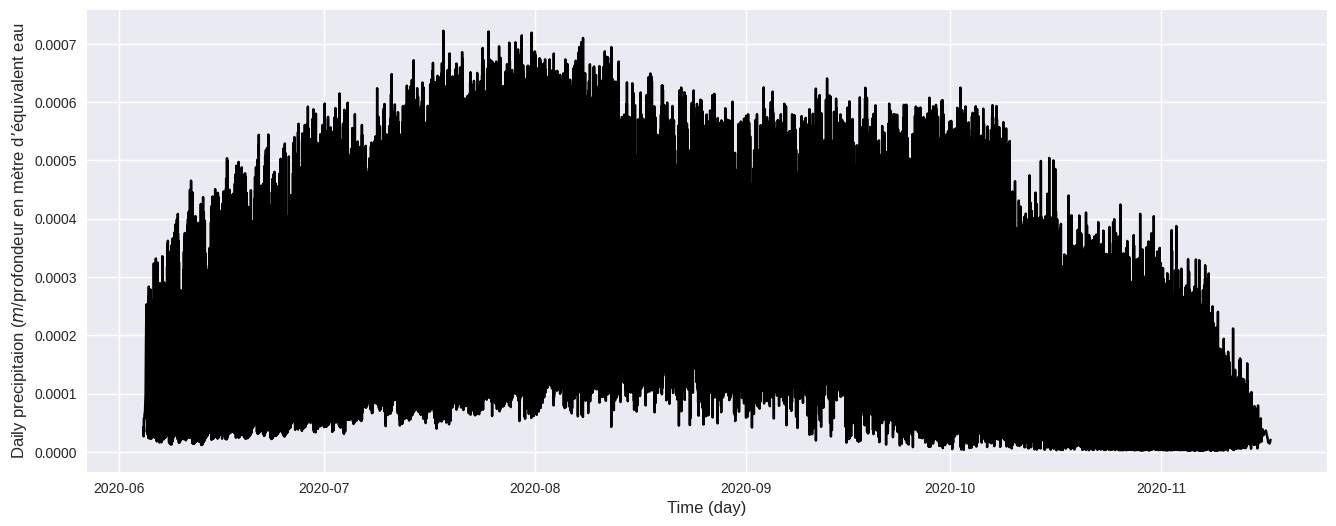

In [7]:
#data= data.sort_index()
# Define a function to draw time_series plot
def timeseries (x_axis, y_axis, x_label, y_label):
    plt.figure(figsize = (16, 6))
    plt.plot(x_axis, y_axis, color ='black')
    plt.xlabel(x_label, {'fontsize': 12})
    plt.ylabel(y_label, {'fontsize': 12})
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/1.jpg', format='jpg', dpi=1000)

timeseries(data.index, data['Total_precip'], 'Time (day)', 
           'Daily precipitaion ($m$/profondeur en mètre d’équivalent eau')


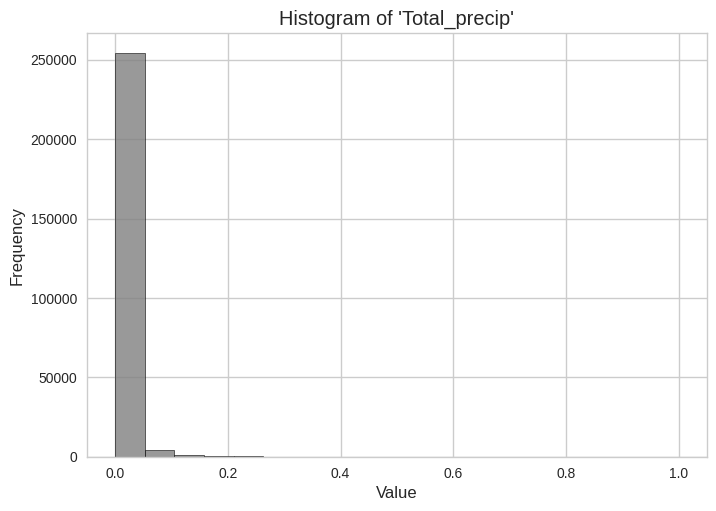

In [55]:
def plot_histogram(x):
    plt.hist(x, bins = 19, alpha=0.8, color = 'gray', edgecolor = 'black')
    plt.title("Histogram of '{var_name}'".format(var_name=x.name))
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plot_histogram(data['Total_precip'])

## Diviser l'ensemble de données en données de formation et de test

Dans ce projet, les premiers 60 % des données sont des données de formation, les 20 %  sont des données de test et les 20 % restants sont des données d'entrainement. J'entraîne le modèle avec les données d'entraînement et je valide ses performances avec les données de test.

Dimension of train data:  (83558, 10)
Dimension of test data:  (20890, 10)


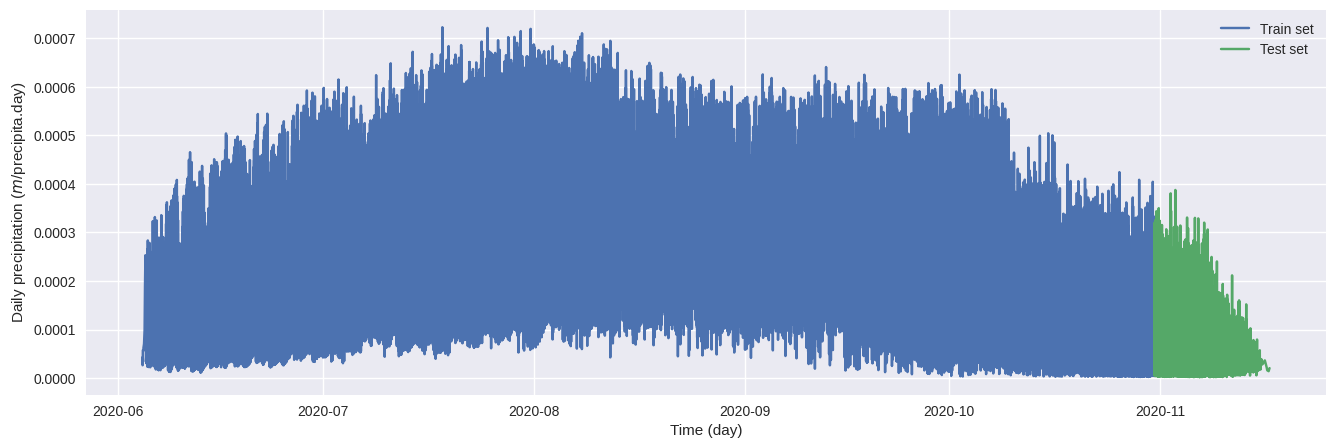

In [14]:
train_size = int(len(generated_data)*0.6)
train_dataset, test_dataset = generated_data.iloc[:train_size], generated_data.iloc[train_size:]

# Plot train and test data
plt.figure(figsize = (16, 5))
plt.plot(train_dataset.Total_precip)
plt.plot(test_dataset.Total_precip)
#plt.plot(validate_data.Total_precip)
plt.xlabel('Time (day)')
plt.ylabel('Daily precipitation ($m$/precipita.day)')
plt.legend(['Train set', 'Test set', 'Validate set'], loc='upper right')
#plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/2.jpg', format='jpg', dpi=1000)

print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)
#print('Dimension of validate data: ',validate_data.shape)


## Lagged Features in Time Series Forcasting 
Lagged Features in Time Series Forecasting

la modélisation prédictive des séries temporelles a souvent besoin d'aide pour prévoir avec précision les valeurs

futures, en particulier en présence de bruit et de modèles sous-jacents complexes.

L'utilisation des variables décalées (lagged features) améliore considérablement la prédiction des séries 

temporelles.

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ===================== Normalisation =====================
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m', 'SST','level', 
            'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']

scaler = MinMaxScaler()
scaler_target = MinMaxScaler()

# Normaliser séparément les features et la target
scaled_features = scaler.fit_transform(
    dataset[['longitude', 'latitude', 'Temp_2m', 'SST','level',
             'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']]
)
scaled_target = scaler_target.fit_transform(dataset[[target_variable]])

# Reconstruction du dataframe normalisé
data = pd.DataFrame(
    np.concatenate([scaled_features, scaled_target], axis=1),
    columns=['longitude', 'latitude', 'Temp_2m', 'SST','level',
             'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind','Total_precip'],
    index=dataset.index
)

# ===================== Création des lag features =====================
# Décalage des features explicatives
for feature in features:
    if feature != target_variable:  # ❌ on évite de lagger la target
        data[feature + '_lag1'] = data[feature].shift(1)

# Décalage de la target pour prédire t+1
data['target'] = data[target_variable].shift(-1)

# Nettoyer les NaN générés par les shifts
data.dropna(inplace=True)

# ===================== Liste finale des features =====================
lag_features = [f + '_lag1' for f in features if f != target_variable]
all_features = features + lag_features

print("✅ Features utilisées:", all_features)
print("✅ Target:", "target")

############################################### Another Split data into training and test sets
train_size = 0.6
validate_size = 0.2
train_data, validate_data, test_data = np.split(data.sample(frac=1), [int(train_size * len(data)), 
                                                          int((validate_size + train_size) * len(data))])

train_data= train_data.sort_index()
test_data= test_data.sort_index()
validate_data= validate_data.sort_index()
############################################
# Prepare data for LSTM
X_train = train_data[all_features].values
y_train = train_data[target_variable].values
X_test = test_data[all_features].values
y_test = test_data[target_variable].values
###########
date_train=train_data.index
date_test=test_data.index
# Reshape data for RNN input: Create a 3D Input Dataset:
## LSTM, GRU and BiLSTM take a 3D input (num_samples, num_timesteps, num_features)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

✅ Features utilisées: ['longitude', 'latitude', 'Temp_2m', 'SST', 'Total_precip', 'level', 'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind', 'longitude_lag1', 'latitude_lag1', 'Temp_2m_lag1', 'SST_lag1', 'level_lag1', 'Rel_hum_lag1', 'Spec_hum_lag1', 'U_wind_lag1', 'V_wind_lag1']
✅ Target: target


/home/oem/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


# Create BiLSTM, LSTM and GRU model
The first function, create_model_bilstm, creates a BDLSM and gets the number of units (neurons) in hidden layers. The second function, *create_model*, gets two inputs; number of units in hidden layers and model name (LSTM or GRU).

For the sake of simplicity, BiLSTM, LSTM and GRU have 2 hidden layers including 64 neurons and 1 neuron in the output layer.

To make the LSTM and GRU networks robust to changes, the Dropout function is used. Dropout(0.2)  randomly drops 20% of units from the network.

In [6]:
# Create BiLSTM model
def create_model_bilstm(units):
    model = Sequential()
    # First layer of BiLSTM
    model.add(Bidirectional(LSTM(units = units, return_sequences=True), 
                            input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.4)) 
    # Second layer of BiLSTM
    model.add(Bidirectional(LSTM(units = units)))
    model.add(Dropout(0.4)) 
    model.add(Dense(1))
    #Compile model
    model.compile(loss='mse', optimizer='adam')
    return model


# Create LSTM or GRU model
def create_model(units, m):
    model = Sequential()
    # First layer of LSTM
    model.add(m (units = units,activation="tanh", return_sequences = True, 
                 input_shape = [X_train.shape[1], X_train.shape[2]]))
    model.add(Dropout(0.4)) 
    # Second layer of LSTM
    model.add(m (units = units,return_sequences=False))                 
    model.add(Dropout(0.4))
    model.add(Dense(units = 1)) 
    #Compile model
    model.compile(loss='mse', optimizer='adam')
    return model


# BiLSTM
model_bilstm = create_model_bilstm(54)

# GRU and LSTM 
model_gru = create_model(54, GRU)
model_lstm = create_model(54, LSTM)

/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Fit the models
I train the model with train data for 100 epoch and batch_size = 16. I get the model to use 20% of train data as validation data. It is important to set shuffle = False because the order of the data matters in our project.

To avoid overfitting, I set an early stop to stop training when "val_loss" has not improved after 10 epochs (patience = 10).


In [7]:
# Fit BiLSTM, LSTM and GRU
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                               patience = 10)

    # shuffle = False because the order of the data matters
    history = model.fit(X_train, y_train, epochs = 88, validation_split = 0.2,
                    batch_size = 16, shuffle = False, callbacks = [early_stop])
    return history

history_bilstm = fit_model(model_bilstm)
history_lstm = fit_model(model_lstm)
history_gru = fit_model(model_gru)

Epoch 1/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0217 - val_loss: 0.0052
Epoch 2/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0138 - val_loss: 0.0026
Epoch 3/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0084 - val_loss: 0.0060
Epoch 4/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 5/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - val_loss: 0.0018
Epoch 6/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - val_loss: 6.0984e-04
Epoch 7/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023 - val_loss: 1.2311e-04
Epoch 8/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - val_loss: 2.9543e-04
Epoch 9/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0020 - val_loss: 2.9870e-04
Epoch 10/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0017 - val_loss: 1.7418e-04
Epoch 11/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017 - val_loss: 1.8493e-04
Epoch 12/88
132/132 ━━━━━━

132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0238 - val_loss: 0.0052
Epoch 2/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0142 - val_loss: 0.0033
Epoch 3/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0088 - val_loss: 0.0049
Epoch 4/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 - val_loss: 0.0020
Epoch 5/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046 - val_loss: 7.8525e-04
Epoch 6/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046 - val_loss: 8.1781e-04
Epoch 7/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042 - val_loss: 8.0322e-04
Epoch 8/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040 - val_loss: 3.6499e-04
Epoch 9/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038 - val_loss: 4.7975e-04
Epoch 10/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - val_loss: 2.7480e-04
Epoch 11/88
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0037 - val_loss: 6.0223e-04
Epoch 12/88
132/132 ━━━━━━━━━━━━━━━

### Plot train loss vs validation loss 

/tmp/ipykernel_80642/2495062194.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


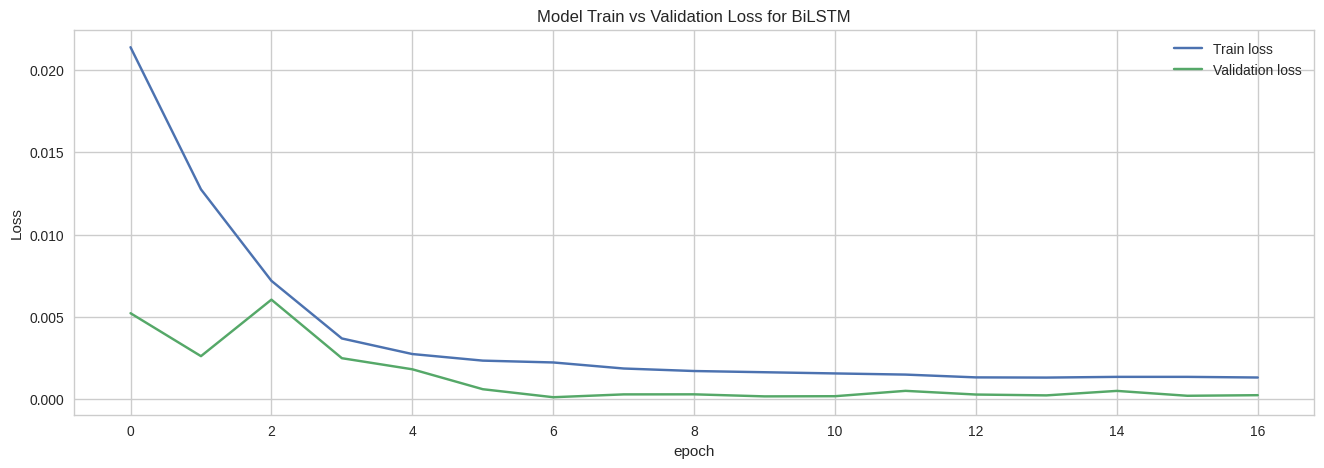

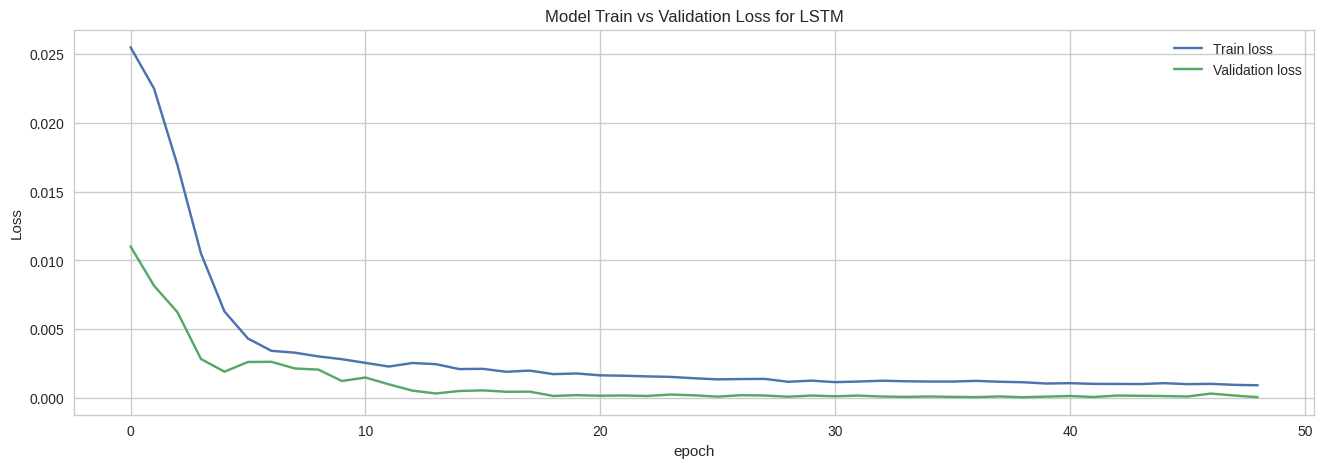

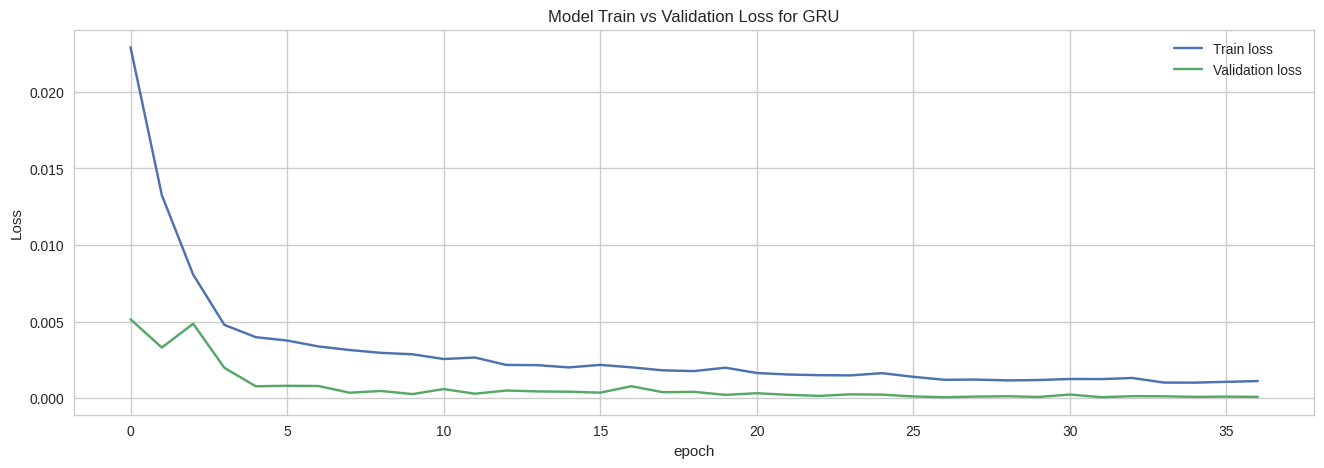

In [8]:
plt.style.use('seaborn-whitegrid')
def plot_loss (history, model_name):
    plt.figure(figsize = (16, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/loss_'+model_name+'.jpg', format='jpg', dpi=1000)

plot_loss (history_bilstm, 'BiLSTM')
plot_loss (history_lstm, 'LSTM')
plot_loss (history_gru, 'GRU')

## Inverse target variable for train and test data

After building the model, I have to transform the target variable back to original data space for train and test 

data using scaler_target.inverse_transform.

# Make prediction using BiLSTM, LSTM and GRU
Here I predict UWC using BiLSTM, LSTM and GRU models. Then, I plot true future vs prediction the three models.

In [9]:
import cmath
def prediction(model):
    prediction = model.predict(X_test)
    prediction = scaler_target.inverse_transform(prediction)
    return prediction

prediction_bilstm = prediction(model_bilstm)
prediction_lstm = prediction(model_lstm)
prediction_gru = prediction(model_gru)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [10]:
y_test=y_test.reshape(-1,1)
y_train=y_train.reshape(-1,1)
Y_test = scaler_target.inverse_transform(y_test)
Y_train = scaler_target.inverse_transform(y_train)

## Plot true future (test) vs prediction

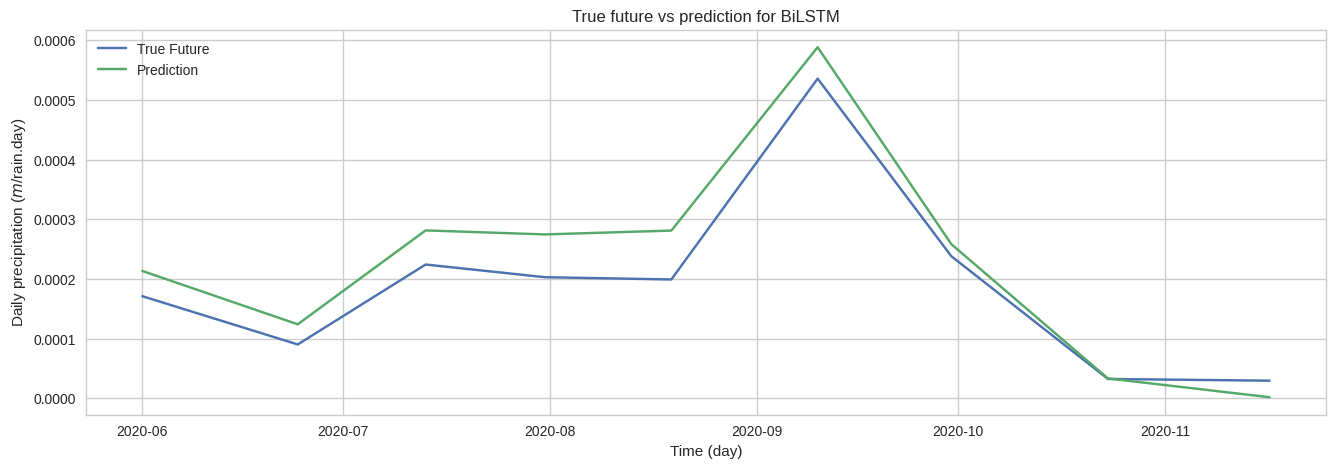

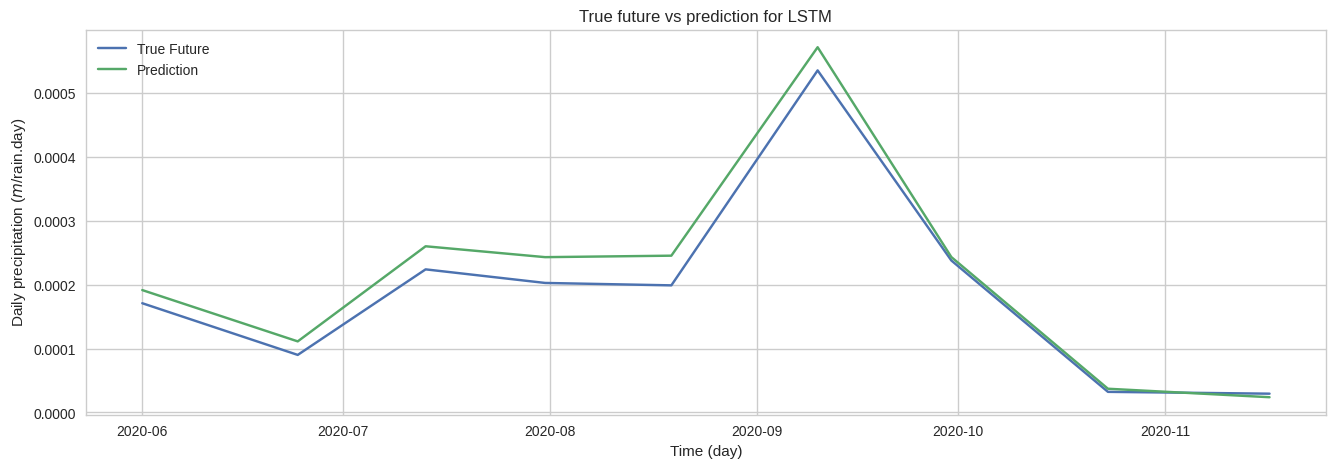

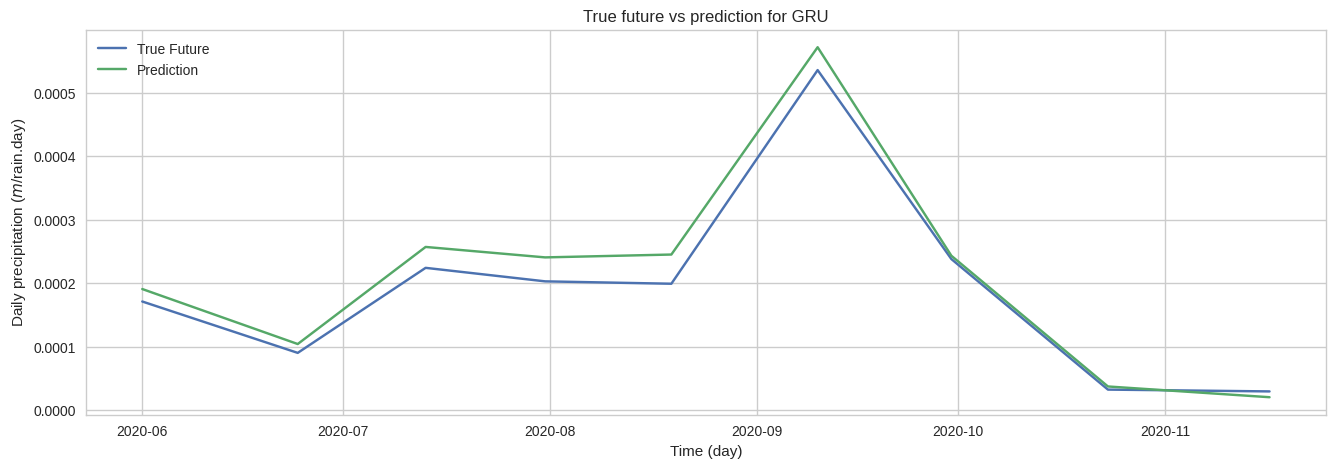

In [11]:
def plot_future(prediction, model_name, y_test):
    
    plt.figure(figsize=(16, 5))
    
    range_future =100

    plt.plot(date_test[::range_future], np.array(Y_test[::range_future]), label='True Future')
    plt.plot(date_test[::range_future], np.array(prediction[::range_future]),label='Prediction')

    plt.title('True future vs prediction for ' + model_name)
    plt.legend(loc='upper left')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/rain.day)')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/predic_'+model_name+'.jpg', format='jpg', dpi=1000)
    
    
plot_future(prediction_bilstm, 'BiLSTM', Y_test)
plot_future(prediction_lstm, 'LSTM', Y_test)
plot_future(prediction_gru, 'GRU', Y_test)

## Calculate MSE , MAE and RMSE

In [12]:
# Define a function to calculate MAE and RMSE
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()

    print(model_name + ':')
    print('Mean Squared  Error: {:.15f}'.format(mse))
    print('Mean Absolute Error: {:.10f}'.format(mae))
    print('Root Mean Square Error: {:.10f}'.format(rmse))
    print('')


evaluate_prediction(prediction_bilstm,Y_test , 'Bidirectional LSTM')
evaluate_prediction(prediction_lstm, Y_test, 'LSTM')
evaluate_prediction(prediction_gru, Y_test, 'GRU')


Bidirectional LSTM:
Mean Squared  Error: 0.000000002560465
Mean Absolute Error: 0.0000437774
Root Mean Square Error: 0.0000506010

LSTM:
Mean Squared  Error: 0.000000000872846
Mean Absolute Error: 0.0000249363
Root Mean Square Error: 0.0000295440

GRU:
Mean Squared  Error: 0.000000000802260
Mean Absolute Error: 0.0000237629
Root Mean Square Error: 0.0000283242



## Conclusion du benchmark

Les résultats montrent que la **LSTM** a les meilleures performances par rapport à la BiLSTM et à la GRU. 

J'utilise donc le modèle LSTM pour la validation. 

## Hystory plot

/tmp/ipykernel_80642/1097592202.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


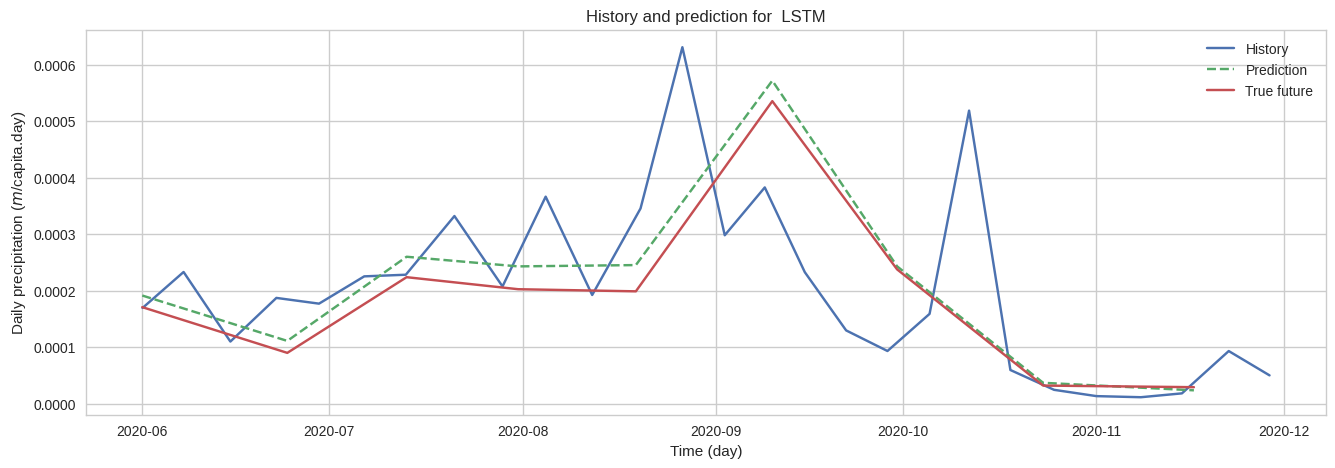

In [13]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

# Plot histoy and future data
colnames =data.loc[:,"Total_precip"].index
def plot_history_future(y_train, prediction, model_name):
    
    plt.figure(figsize=(16, 5))
    range_future = 100
    date_prediction=date_test[::range_future]
    range_history = 100
    date_history=date_train[::range_history]
    #date_test=date_test[:]
    #range_future = list(range(range_history, range_history + len(prediction)))

    plt.plot(date_history, np.array(Y_train[::range_history]), label='History')
    plt.plot(date_prediction, np.array(prediction[::range_future]),label='Prediction',linestyle='--')
    plt.plot(date_prediction, np.array(Y_test[::range_future]),label='True future')
    plt.title('History and prediction for ' + model_name)
    plt.legend(loc='upper right')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/capita.day)')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/3.jpg', format='jpg', dpi=1000)
plot_history_future(Y_train, prediction_lstm, ' LSTM')

# Test de Validation

In [14]:
X_val = validate_data[all_features].values
y_val = validate_data[target_variable].values
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
def prediction(model):
    prediction = model.predict(X_val)
    prediction = scaler_target.inverse_transform(prediction)
    return prediction

Prediction = prediction(model_lstm)
y_val=y_val.reshape(-1,1)
Y_val = scaler_target.inverse_transform(y_val)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/tmp/ipykernel_80642/1315784545.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


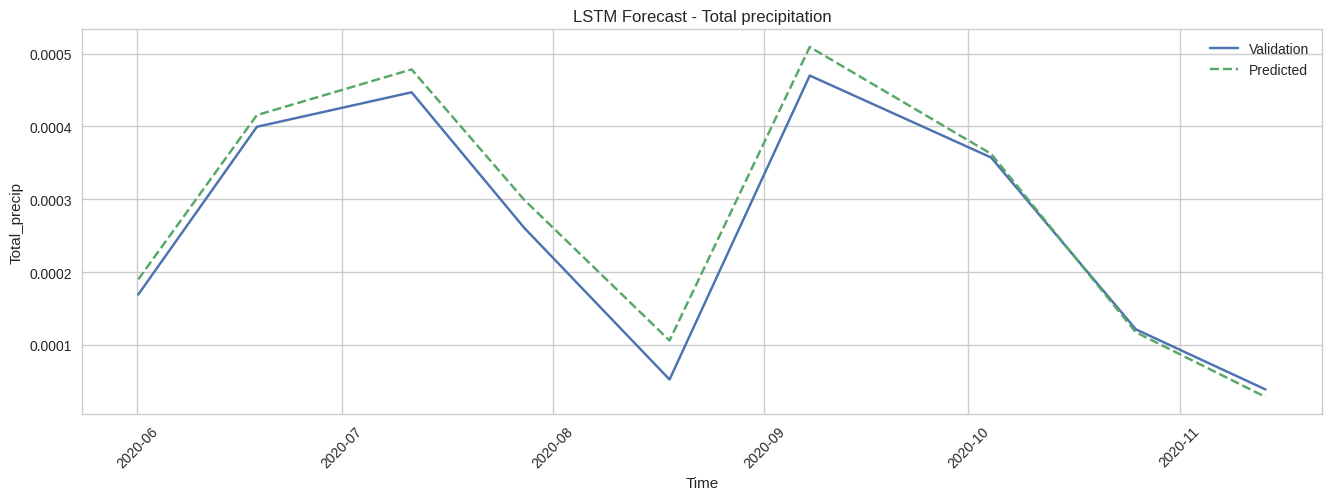

In [15]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
## Visualisation échantillon
range_validation = 100
plt.figure(figsize=(16, 5))
plt.plot(validate_data.index[::range_validation], Y_val[::range_validation], label='Validation')
plt.plot(validate_data.index[::range_validation], Prediction[::range_validation], label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation')
plt.legend()
plt.show()

# Benchmark  avec les données synthétique générées par TimeGAN

Nous allons faire le même travail de comparaison sur les  différentes variantes de RNN ('Bidirectional LSTM, LSTM et 

GRU) avec une base de données générées par TimeGAN.

L'objectif est de tester si les données synthétiques garderons les mêmes propriétés que les données réelles 

In [3]:
## Chargement des données synthétique au format h5
df = pd.read_hdf('/home/oem/Documents/these/code/test_timGAN3/time_gan/TimeSeriesGAN.h5')
# Permet de ramener time au format datetime 
df['time'] = pd.to_datetime(df['time']).round('min')
df= df.set_index('time')
## Ordonner selon le time
df=df.sort_index()
print(df.shape)

(104448, 10)


In [4]:
df.head()

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-04 12:33:00,-5.0,11.0,300.933533,64.295479,0.000030,570.753906,50.462017,0.005164,-5.882304,2.732146
2020-06-04 12:33:00,-5.0,11.0,302.026764,64.294472,0.000042,570.753906,49.941395,0.005111,-5.749994,2.609848
2020-06-04 13:12:00,-5.0,11.0,300.290802,64.308510,0.000031,570.753906,53.308689,0.005470,-5.444100,3.356772
2020-06-04 13:32:00,-5.0,11.0,300.038635,64.300621,0.000026,570.753906,51.908276,0.005383,-5.253638,3.287252
2020-06-04 14:14:00,-5.0,11.0,299.851379,64.307526,0.000027,570.753906,53.983742,0.005750,-3.849236,3.657254


## Chargement de la base synthétique de TimeGAN 

In [3]:
df= pd.read_csv('/home/oem/Documents/these/code/test_timGAN3/generated_dataset.csv', 
                  index_col='time',  parse_dates=['time']).sort_index()
df = df.reset_index()
df

,time,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
0,2020-06-15 12:00:41.952772096,2.170534,9.893143,300.86280,0.009148,0.000110,964.476140,68.315550,0.014408,-4.360369,-1.780995
1,2020-06-15 18:30:06.574862336,-12.121690,15.872870,304.78000,0.000009,0.000042,451.572420,85.582900,0.002967,-3.771595,4.051870
2,2020-06-15 18:41:33.769629696,3.245456,10.816600,300.57605,0.000013,0.000084,125.741264,73.224080,0.000030,-17.304035,7.523895
3,2020-06-15 19:38:49.743466496,9.710560,7.253951,297.05060,0.000031,0.000081,299.455960,39.438416,0.000432,-17.857906,6.375463
4,2020-06-15 20:06:19.010908160,5.461076,11.454701,299.81470,0.005540,0.000099,969.440400,67.131330,0.014606,-6.798019,-2.371804
...,...,...,...,...,...,...,...,...,...,...,...
6248443,2020-11-30 06:26:18.619650048,-3.319306,13.421268,298.68912,0.000021,0.000023,995.753900,47.217537,0.014540,3.847840,-4.751749
6248444,2020-11-30 06:30:53.497556992,-4.648334,5.030470,298.20416,295.461940,0.000001,997.023740,25.699263,0.011661,13.243396,-6.019631
6248445,2020-11-30 06:30:53.497556992,-2.217730,7.404860,291.67212,0.000049,0.000304,941.504800,77.617820,0.014171,-8.340811,5.049771
6248446,2020-11-30 06:33:10.936510464,-13.501818,15.616605,299.69424,0.000011,0.000022,991.769400,47.772790,0.012992,5.281574,-5.297015


## Chargement du dataset de validation (real data)

In [4]:
df_val= pd.read_csv('data_validation.csv', 
                  index_col='time',  parse_dates=['time']).sort_index()
df_val

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 00:00:00,-11.50,17.00,307.91928,0.0,0.000000,825,86.197110,0.012359,-6.609961,-1.715261
2020-06-01 00:00:00,2.25,9.00,299.04245,0.0,0.000000,200,68.657814,0.000055,-11.955005,-2.550896
2020-06-01 00:00:00,8.50,6.25,299.61820,0.0,0.000000,200,92.865440,0.000080,8.239785,17.425602
2020-06-01 00:00:00,4.75,13.75,305.04047,0.0,0.000000,825,75.621290,0.011340,-5.986229,0.485104
2020-06-01 00:00:00,8.75,11.00,299.72604,0.0,0.000000,200,96.846070,0.000081,7.090500,12.761374
...,...,...,...,...,...,...,...,...,...,...
2020-11-30 23:00:00,0.00,13.75,298.79306,0.0,0.000000,700,73.155610,0.007840,-5.535755,3.523202
2020-11-30 23:00:00,5.00,11.25,297.16238,0.0,0.000000,700,68.472370,0.007207,-12.044520,3.780401
2020-11-30 23:00:00,-12.75,13.75,297.41235,0.0,0.000000,100,59.808502,0.000002,-0.076650,5.373986


## To do !! Arrondir les paramétres time (en H) ensuite  
## latitude et  longitude(au centiémes prés) et level (à l'unité prés)
## valider l'apprentissage avec les données réelles du dataset initiale

In [5]:
# Permet de ramener time au format datetime apres le test
df['time'] = pd.to_datetime(df['time']).dt.round('H')
# Arrondir les coordonnées
df['latitude'] = df['latitude'].round(2)
df['longitude'] = df['longitude'].round(2)
df['level'] = df['level'].round(0)
df

/tmp/ipykernel_15413/3876013556.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['time'] = pd.to_datetime(df['time']).dt.round('H')


,time,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
0,2020-06-15 12:00:00,2.17,9.89,300.86280,0.009148,0.000110,964.0,68.315550,0.014408,-4.360369,-1.780995
1,2020-06-15 19:00:00,-12.12,15.87,304.78000,0.000009,0.000042,452.0,85.582900,0.002967,-3.771595,4.051870
2,2020-06-15 19:00:00,3.25,10.82,300.57605,0.000013,0.000084,126.0,73.224080,0.000030,-17.304035,7.523895
3,2020-06-15 20:00:00,9.71,7.25,297.05060,0.000031,0.000081,299.0,39.438416,0.000432,-17.857906,6.375463
4,2020-06-15 20:00:00,5.46,11.45,299.81470,0.005540,0.000099,969.0,67.131330,0.014606,-6.798019,-2.371804
...,...,...,...,...,...,...,...,...,...,...,...
6248443,2020-11-30 06:00:00,-3.32,13.42,298.68912,0.000021,0.000023,996.0,47.217537,0.014540,3.847840,-4.751749
6248444,2020-11-30 07:00:00,-4.65,5.03,298.20416,295.461940,0.000001,997.0,25.699263,0.011661,13.243396,-6.019631
6248445,2020-11-30 07:00:00,-2.22,7.40,291.67212,0.000049,0.000304,942.0,77.617820,0.014171,-8.340811,5.049771
6248446,2020-11-30 07:00:00,-13.50,15.62,299.69424,0.000011,0.000022,992.0,47.772790,0.012992,5.281574,-5.297015


In [6]:
# Ordonner le dataset selon la date et l'heure
df = df.set_index("time").sort_index()
df

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-15 12:00:00,2.17,9.89,300.86280,0.009148,0.000110,964.0,68.315550,0.014408,-4.360369,-1.780995
2020-06-15 19:00:00,-12.12,15.87,304.78000,0.000009,0.000042,452.0,85.582900,0.002967,-3.771595,4.051870
2020-06-15 19:00:00,3.25,10.82,300.57605,0.000013,0.000084,126.0,73.224080,0.000030,-17.304035,7.523895
2020-06-15 20:00:00,9.71,7.25,297.05060,0.000031,0.000081,299.0,39.438416,0.000432,-17.857906,6.375463
2020-06-15 20:00:00,5.46,11.45,299.81470,0.005540,0.000099,969.0,67.131330,0.014606,-6.798019,-2.371804
...,...,...,...,...,...,...,...,...,...,...
2020-11-30 06:00:00,-3.32,13.42,298.68912,0.000021,0.000023,996.0,47.217537,0.014540,3.847840,-4.751749
2020-11-30 07:00:00,-4.65,5.03,298.20416,295.461940,0.000001,997.0,25.699263,0.011661,13.243396,-6.019631
2020-11-30 07:00:00,-2.22,7.40,291.67212,0.000049,0.000304,942.0,77.617820,0.014171,-8.340811,5.049771


##  Pipeline complet avec lagged features

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import Sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import Input
# ===================== Variables =====================
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m', 'SST','level',
            'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']

# ===================== DataGenerator =====================
class LSTMDataGenerator(Sequence):
    def __init__(self, df, features, target_variable, scaler=None, scaler_target=None, batch_size=128, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.df = df.copy()
        self.features = features
        self.target_variable = target_variable
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df)-1)
        self.scaler = scaler
        self.scaler_target = scaler_target
        self.on_epoch_end()


    def __len__(self):
        return int(np.ceil(len(self.indexes)/self.batch_size))

    def __getitem__(self, idx):
        batch_indexes = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        X_batch = []
        y_batch = []

        for i in batch_indexes:
            row = self.df.iloc[i].copy()
            # Lag features
            x_row = row[self.features].values
            lag_features = self.df.iloc[i-1][[f for f in self.features if f != self.target_variable]].values if i>0 else np.zeros_like(x_row)
            x_row = np.concatenate([x_row, lag_features])
            
            # Normalisation
            if self.scaler:
                tmp_df = pd.DataFrame([x_row[:len(self.features)]], columns=self.features)
                x_row[:len(self.features)] = self.scaler.transform(tmp_df)[0]

                y_val = row[self.target_variable]
            if self.scaler_target:
                tmp_target_df = pd.DataFrame([[y_val]], columns=[self.target_variable])
                y_val = self.scaler_target.transform(tmp_target_df)[0,0]


            X_batch.append(x_row)
            y_batch.append(y_val)

        X_batch = np.array(X_batch).reshape((len(X_batch),1,len(X_batch[0])))
        y_batch = np.array(y_batch)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# ===================== Scalers =====================
# Conversion target m -> mm
df[target_variable] = df[target_variable]*1000
df_val[target_variable] = df_val[target_variable]*1000

scaler = MinMaxScaler()
scaler_target = MinMaxScaler()

# Fit scalers sur dataset d'apprentissage seulement
scaler.fit(df[features])
scaler_target.fit(df[[target_variable]])

# ===================== Création des générateurs =====================
batch_size = 128
train_gen = LSTMDataGenerator(df, features, target_variable, scaler, scaler_target, batch_size=batch_size, shuffle=True)
val_gen   = LSTMDataGenerator(df_val, features, target_variable, scaler, scaler_target, batch_size=batch_size, shuffle=False)

# Exemple : vérifier un batch
X_batch, y_batch = train_gen[0]
print("Shape X batch:", X_batch.shape)
print("Shape y batch:", y_batch.shape)

# ===================== Modèles =====================
# Récupérer input_shape depuis un batch
input_shape = (X_batch.shape[1], X_batch.shape[2])

def create_model_bilstm(units, input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Bidirectional(LSTM(units=units, return_sequences=True)))
    model.add(Dropout(0.4))
    model.add(Bidirectional(LSTM(units=units)))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    return model

def create_model(units, m, input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(units=units, return_sequences=True, activation="tanh"))
    model.add(Dropout(0.4))
    model.add(m(units=units, return_sequences=False))
    model.add(Dropout(0.4))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    return model

# Instanciation
model_bilstm = create_model_bilstm(54, input_shape)
model_lstm   = create_model(54, LSTM, input_shape)
model_gru    = create_model(54, GRU, input_shape)

# ===================== Entraînement =====================
def fit_model(model, train_gen, val_gen, model_name, epochs=88):
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f"best_{model_name}.h5", monitor='val_loss', save_best_only=True ,verbose=1)
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[early_stop, checkpoint],
        shuffle=False
    )
    return history

history_bilstm = fit_model(model_bilstm, train_gen, val_gen, "bilstm")
history_lstm   = fit_model(model_lstm, train_gen, val_gen, "lstm")
history_gru    = fit_model(model_gru, train_gen, val_gen, "gru")


Shape X batch: (128, 1, 18)
Shape y batch: (128,)


2025-09-29 18:45:38.722676: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/88
48809/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 506ms/step - loss: 0.0011
Epoch 1: val_loss improved from None to 0.00334, saving model to best_bilstm.h5


48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25720s 527ms/step - loss: 9.1310e-04 - val_loss: 0.0033
Epoch 2/88
48809/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - loss: 8.3010e-04
Epoch 2: val_loss did not improve from 0.00334
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25131s 515ms/step - loss: 8.2754e-04 - val_loss: 0.0034
Epoch 3/88
48809/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - loss: 8.2048e-04
Epoch 3: val_loss did not improve from 0.00334
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25179s 516ms/step - loss: 8.2222e-04 - val_loss: 0.0033
Epoch 4/88
48808/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - loss: 8.1430e-04
Epoch 4: val_loss did not improve from 0.00334
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25195s 516ms/step - loss: 8.0814e-04 - val_loss: 0.0033
Epoch 5/88
48808/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - loss: 7.6559e-04
Epoch 5: val_loss did not improve from 0.00334
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25191s 516ms/step - loss: 7.3359e-04 - val_loss: 0.0046
Epoch 6/88
48809/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 496ms/step -

48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25418s 521ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 2/88
48808/48816 ━━━━━━━━━━━━━━━━━━━━ 4s 502ms/step - loss: 0.0011 
Epoch 2: val_loss did not improve from 0.00337
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25557s 524ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 3/88
48810/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - loss: 0.0011
Epoch 3: val_loss improved from 0.00337 to 0.00336, saving model to best_lstm.h5


48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25435s 521ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 4/88
48808/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - loss: 0.0011
Epoch 4: val_loss did not improve from 0.00336
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25322s 519ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 5/88
48808/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - loss: 0.0011
Epoch 5: val_loss did not improve from 0.00336
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25350s 519ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 6/88
48810/48816 ━━━━━━━━━━━━━━━━━━━━ 2s 499ms/step - loss: 0.0011
Epoch 6: val_loss did not improve from 0.00336
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25405s 520ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 7/88
48813/48816 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step - loss: 0.0011
Epoch 7: val_loss did not improve from 0.00336
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25444s 521ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 8/88
48814/48816 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step - loss: 0.0011
Epoch 8: val_loss did 

48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25427s 521ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 11/88
48810/48816 ━━━━━━━━━━━━━━━━━━━━ 3s 501ms/step - loss: 0.0011
Epoch 11: val_loss did not improve from 0.00336
48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25476s 522ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 12/88
48808/48816 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - loss: 0.0011 
Epoch 12: val_loss improved from 0.00336 to 0.00336, saving model to best_lstm.h5


48816/48816 ━━━━━━━━━━━━━━━━━━━━ 25604s 524ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 13/88
  213/48816 ━━━━━━━━━━━━━━━━━━━━ 6:51:24 508ms/step - loss: 0.0011

## Recharger directement les modéles 

In [8]:
from tensorflow.keras.models import load_model

bilstm_model = load_model("best_bilstm.h5")
lstm_model   = load_model("best_lstm.h5")
gru_model    = load_model("best_gru.h5")


2025-09-22 16:51:35.342240: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/oem/anaconda3/envs/climate-env/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/envs/climate-env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Plot train loss vs validation loss

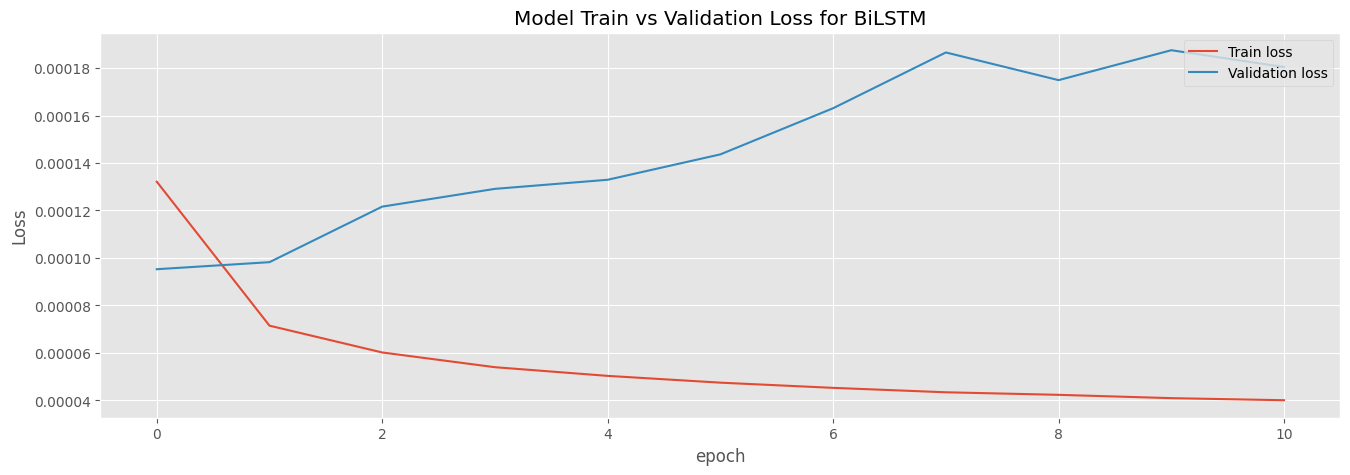

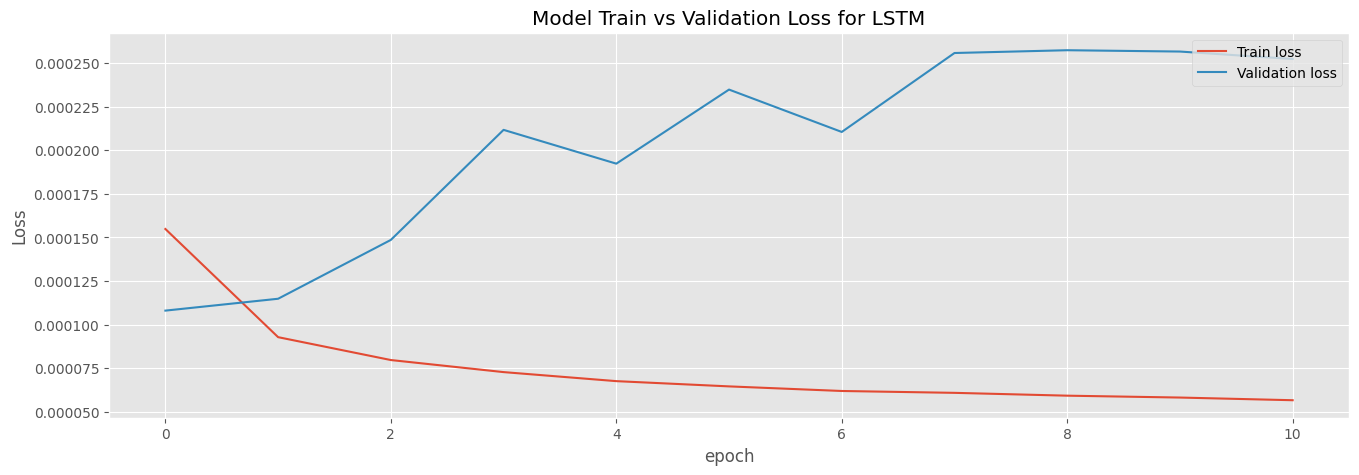

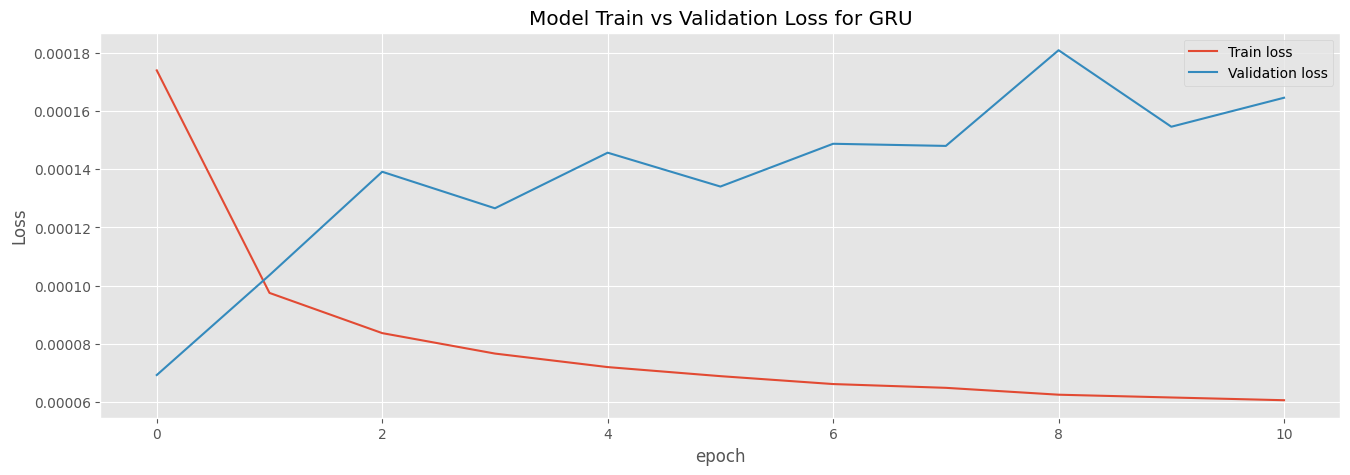

In [10]:
def plot_loss (history, model_name):
    #plt.style.use('seaborn')
   #plt.style.use('fivethirtyeight')
   #plt.style.use('seaborn-whitegrid')
    plt.style.use('ggplot')
    plt.figure(figsize = (16, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    plt.savefig('/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/loss_'+model_name+'.jpg', format='jpg', dpi=1000)

plot_loss (history_bilstm, 'BiLSTM')
plot_loss (history_lstm, 'LSTM')
plot_loss (history_gru, 'GRU')

## Make prediction using BiLSTM, LSTM and GRU

In [11]:
# ===================== Prédictions avec DataGenerator =====================
def predict_with_generator(model, generator, scaler_target=None):
    y_pred = []
    for i in range(len(generator)):
        X_batch, _ = generator[i]  # on ignore y réel
        y_batch_pred = model.predict(X_batch, verbose=0)
        y_pred.append(y_batch_pred)
    y_pred = np.vstack(y_pred)
    
    if scaler_target:
        y_pred = scaler_target.inverse_transform(y_pred)
    
    return y_pred

# Exemple avec les modèles sauvegardés
prediction_bilstm = predict_with_generator(model_bilstm, test_gen, scaler_target)
prediction_lstm  = predict_with_generator(model_lstm,  test_gen, scaler_target)
prediction_gru   = predict_with_generator(model_gru,   test_gen, scaler_target)


39053/39053 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step
39053/39053 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step
39053/39053 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step


In [12]:
# ===================== Récupérer les vraies valeurs dénormalisées =====================
def get_true_values(generator, scaler_target):
    y_true = []
    for i in range(len(generator)):
        _, y_batch = generator[i]  # récupère les vraies valeurs
        y_true.append(y_batch)
    y_true = np.hstack(y_true).reshape(-1, 1)
    y_true = scaler_target.inverse_transform(y_true)
    return y_true

# Apprentissage
Y_train = get_true_values(train_gen, scaler_target)

# Test
Y_test = get_true_values(test_gen, scaler_target)

# Validation si nécessaire
Y_val = get_true_values(val_gen, scaler_target)


## Plot true future (test)  vs prediction

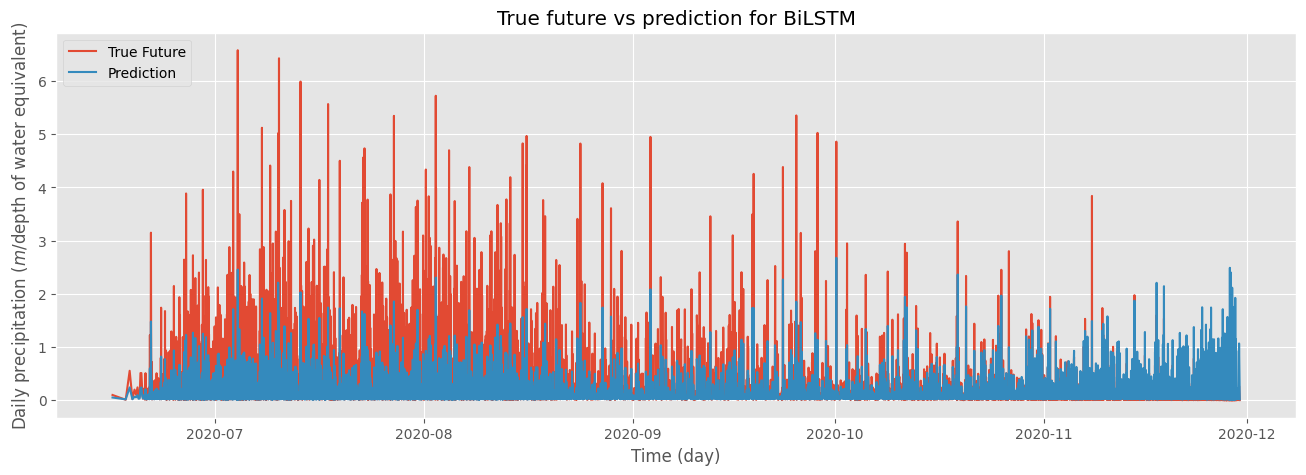

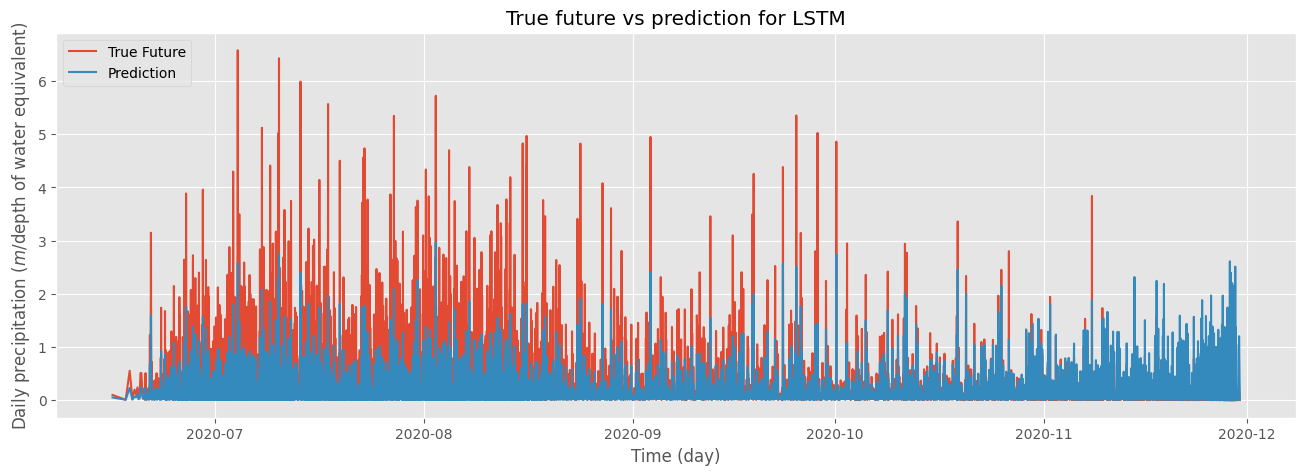

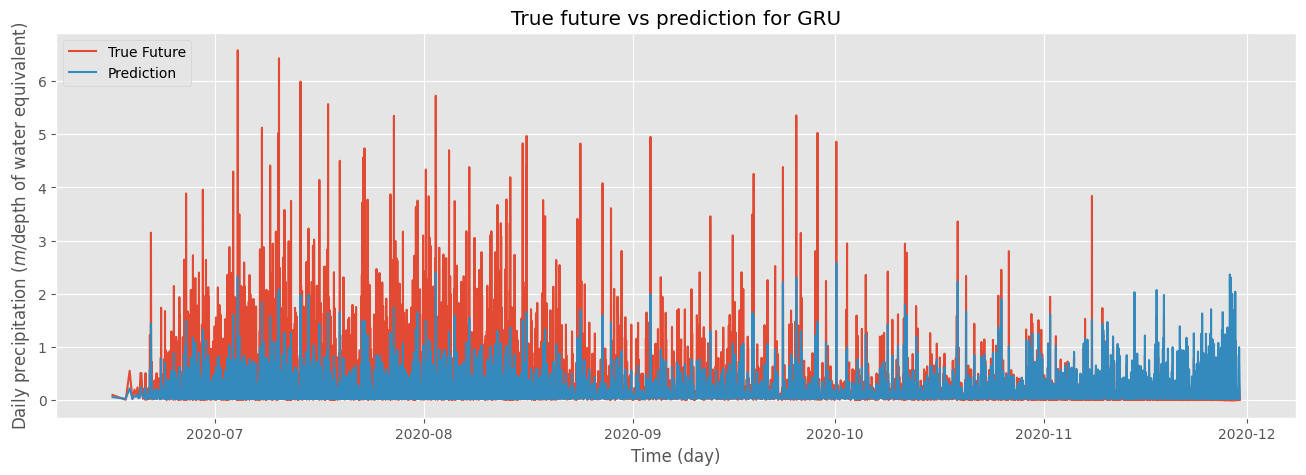

In [13]:
def plot_future(prediction, model_name, y_test):
    
    plt.figure(figsize=(16, 5))
    
    range_future =100

    plt.plot(date_test[::range_future], np.array(Y_test[::range_future]), label='True Future')
    plt.plot(date_test[::range_future], np.array(prediction[::range_future]),label='Prediction')

    plt.title('True future vs prediction for ' + model_name)
    plt.legend(loc='upper left')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/depth of water equivalent)')
    plt.savefig('/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/predic_'+model_name+'.jpg', format='jpg', dpi=1000)
    
    
plot_future(prediction_bilstm, 'BiLSTM', Y_test)
plot_future(prediction_lstm, 'LSTM', Y_test)
plot_future(prediction_gru, 'GRU', Y_test)

## Calculate MSE , MAE and RMSE

In [14]:
# Define a function to calculate MAE and RMSE
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()

    print(model_name + ':')
    print('Mean Squared  Error: {:.15f}'.format(mse))
    print('Mean Absolute Error: {:.10f}'.format(mae))
    print('Root Mean Square Error: {:.10f}'.format(rmse))
    print('')


evaluate_prediction(prediction_bilstm,Y_test , 'Bidirectional LSTM')
evaluate_prediction(prediction_lstm, Y_test, 'LSTM')
evaluate_prediction(prediction_gru, Y_test, 'GRU')


Bidirectional LSTM:
Mean Squared  Error: 0.117501800332368
Mean Absolute Error: 0.1549545279
Root Mean Square Error: 0.3427853561

LSTM:
Mean Squared  Error: 0.106757234475612
Mean Absolute Error: 0.1520250557
Root Mean Square Error: 0.3267372560

GRU:
Mean Squared  Error: 0.120229390057889
Mean Absolute Error: 0.1546066451
Root Mean Square Error: 0.3467410995



In [16]:
E=0.0000385525-0.0000424699
E

-3.9173999999999974e-06

             MSE       MAE      RMSE
BiLSTM  0.117502  0.154955  0.342785
LSTM    0.106757  0.152025  0.326737
GRU     0.120229  0.154607  0.346741


<Figure size 800x600 with 0 Axes>

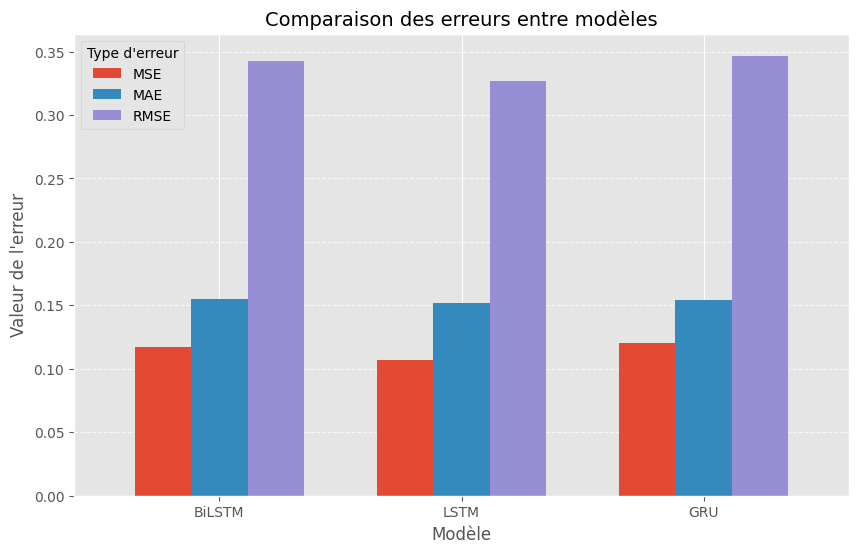

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# ===================== Données =====================
data = [
    {'MSE': 0.117501800332368, 'MAE': 0.1549545279, 'RMSE': 0.3427853561},
    {'MSE': 0.106757234475612, 'MAE': 0.1520250557, 'RMSE': 0.3267372560},
    {'MSE': 0.120229390057889, 'MAE': 0.1546066451, 'RMSE': 0.3467410995}
]

data_error = pd.DataFrame(data, index=['BiLSTM', 'LSTM', 'GRU'])

print(data_error)

# ===================== Graphique =====================
plt.figure(figsize=(8,6))
data_error.plot(kind="bar", figsize=(10,6), width=0.7)

plt.title("Comparaison des erreurs entre modèles", fontsize=14)
plt.ylabel("Valeur de l'erreur", fontsize=12)
plt.xlabel("Modèle", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Type d'erreur")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


             MSE       MAE      RMSE
BiLSTM  0.117502  0.154955  0.342785
LSTM    0.106757  0.152025  0.326737
GRU     0.120229  0.154607  0.346741


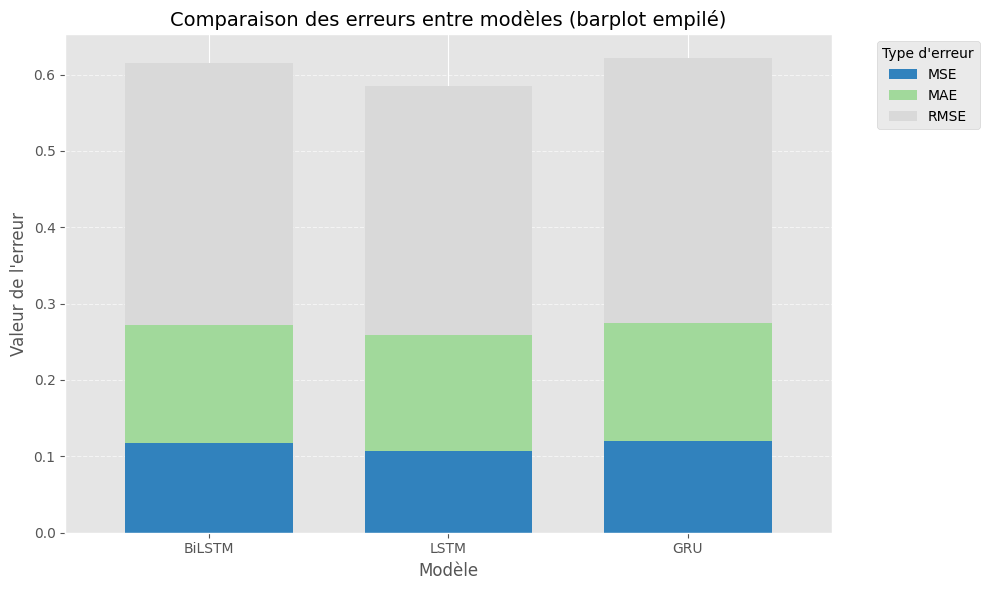

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# ===================== Données =====================
data = [
    {'MSE': 0.117501800332368, 'MAE': 0.1549545279, 'RMSE': 0.3427853561},
    {'MSE': 0.106757234475612, 'MAE': 0.1520250557, 'RMSE': 0.3267372560},
    {'MSE': 0.120229390057889, 'MAE': 0.1546066451, 'RMSE': 0.3467410995}
]

data_error = pd.DataFrame(data, index=['BiLSTM', 'LSTM', 'GRU'])

print(data_error)

# ===================== Graphique empilé =====================
ax = data_error.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="tab20c",
    width=0.7
)

plt.title("Comparaison des erreurs entre modèles (barplot empilé)", fontsize=14)
plt.ylabel("Valeur de l'erreur", fontsize=12)
plt.xlabel("Modèle", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Type d'erreur", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## Conclusion du benchmark

Les résultats montrent que la **LSTM** a les meilleures performances par rapport à la BiLSTM et à la GRU. 

J'utilise donc le modèle LSTM pour la validation. 

## Hystory plot 

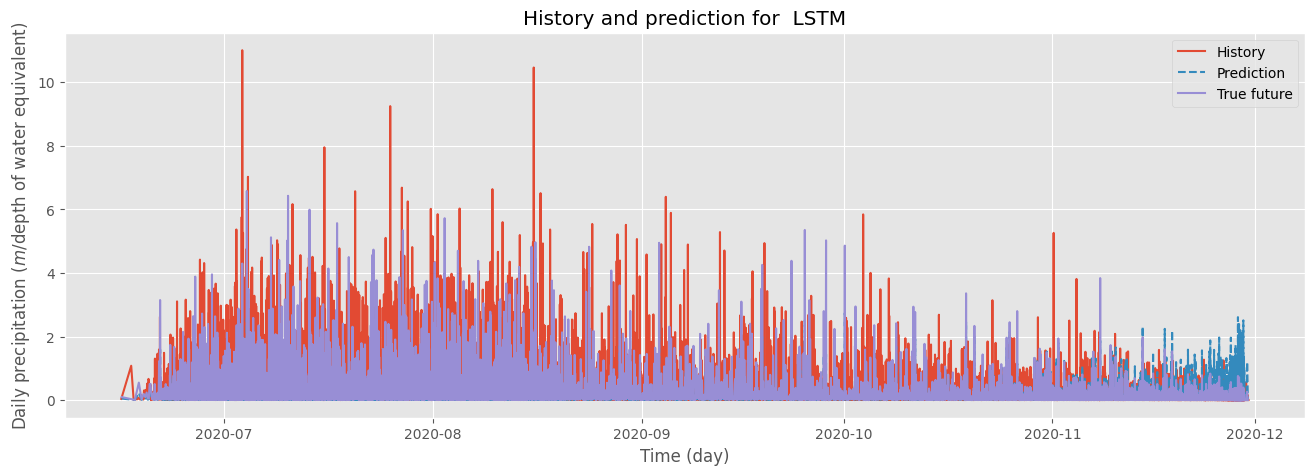

In [18]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
#plt.style.use('seaborn-whitegrid')
plt.style.use('ggplot')

# Plot histoy and future data
colnames =df.loc[:,"Total_precip"].index
def plot_history_future(y_train, prediction, model_name):
    
    plt.figure(figsize=(16, 5))
    range_future = 100
    date_prediction=date_test[::range_future]
    range_history = 100
    date_history=date_train[::range_history]
    #date_test=date_test[:]
    #range_future = list(range(range_history, range_history + len(prediction)))

    plt.plot(date_history, np.array(Y_train[::range_history]), label='History')
    plt.plot(date_prediction, np.array(prediction[::range_future]),label='Prediction',linestyle='--')
    plt.plot(date_prediction, np.array(Y_test[::range_future]),label='True future')
    plt.title('History and prediction for ' + model_name)
    plt.legend(loc='upper right')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/depth of water equivalent)')
    plt.savefig('/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/history.jpg', format='jpg', dpi=1000)
plot_history_future(Y_train, prediction_lstm, ' LSTM')

##  Test de Validation

In [19]:
# ===================== Prédictions sur validation =====================
def predict_with_generator(model, generator, scaler_target=None):
    y_pred = []
    for i in range(len(generator)):
        X_batch, _ = generator[i]  # on ignore y réel
        y_batch_pred = model.predict(X_batch, verbose=0)
        y_pred.append(y_batch_pred)
    y_pred = np.vstack(y_pred)
    
    if scaler_target:
        y_pred = scaler_target.inverse_transform(y_pred)
    
    return y_pred

def get_true_values(generator, scaler_target):
    y_true = []
    for i in range(len(generator)):
        _, y_batch = generator[i]  # récupère les vraies valeurs
        y_true.append(y_batch)
    y_true = np.hstack(y_true).reshape(-1,1)
    y_true = scaler_target.inverse_transform(y_true)
    return y_true

# ===================== Prédictions sur validation pour tous les modèles =====================
Prediction_val_bilstm = predict_with_generator(model_bilstm, val_gen, scaler_target)
Prediction_val_lstm  = predict_with_generator(model_lstm,  val_gen, scaler_target)
Prediction_val_gru   = predict_with_generator(model_gru,   val_gen, scaler_target)

# Valeurs réelles dénormalisées
Y_val = get_true_values(val_gen, scaler_target)

# Vérification des shapes
print("Shape Y_val:", Y_val.shape)
print("Shape Prediction_val_bilstm:", Prediction_val_bilstm.shape)
print("Shape Prediction_val_lstm:", Prediction_val_lstm.shape)
print("Shape Prediction_val_gru:", Prediction_val_gru.shape)


39053/39053 ━━━━━━━━━━━━━━━━━━━━ 67s 2ms/step


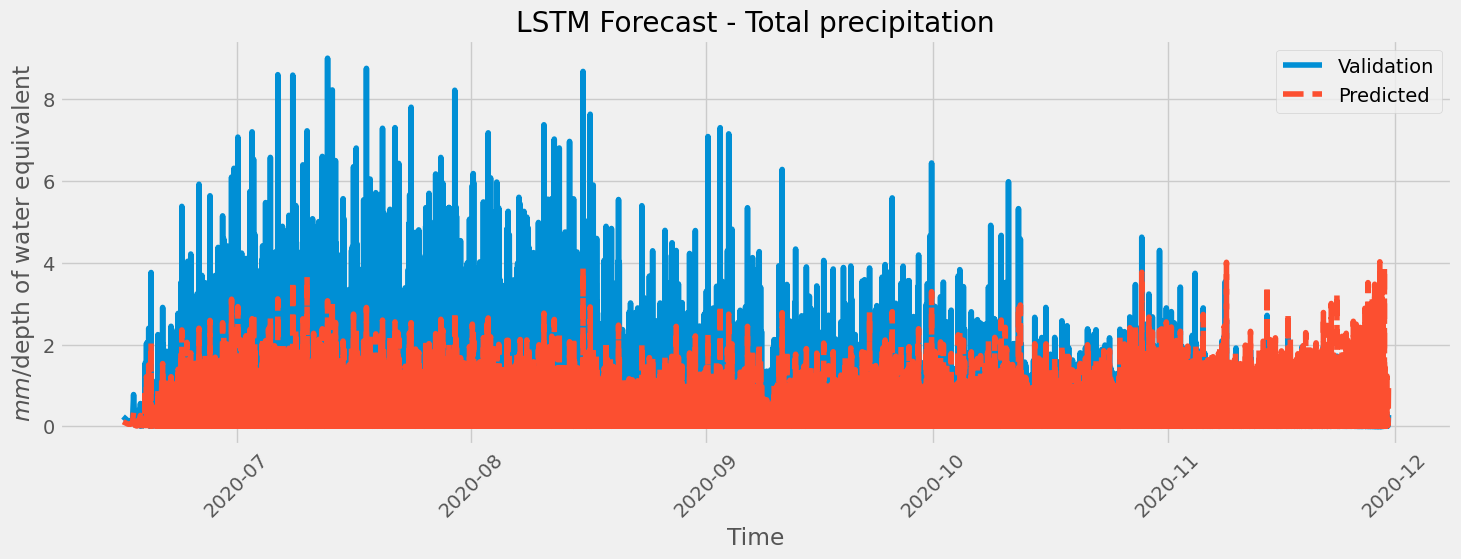

In [23]:
# Visualization
#plt.style.use('seaborn')
plt.style.use('fivethirtyeight')
#plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
## Visualisation échantillon
range_validation = 10
plt.figure(figsize=(16, 5))
plt.plot(validate_synthetic.index[::range_validation], Y_val[::range_validation], label='Validation')
plt.plot(validate_synthetic.index[::range_validation], Prediction[::range_validation], label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('$mm$/depth of water equivalent')
plt.title('LSTM Forecast - Total precipitation')
plt.savefig('/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/validation.jpg', format='jpg', dpi=1000)
plt.legend()
plt.show()

## Calculate MSE , MAE and RMSE with validation data

In [ ]:
# ===================== Évaluation sur données de validation =====================
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse  = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae  = np.abs(errors).mean()

    print(f'{model_name}:')
    print(f'Mean Squared  Error: {mse:.15f}')
    print(f'Mean Absolute Error: {mae:.10f}')
    print(f'Root Mean Square Error: {rmse:.10f}\n')

# Évaluation sur validation
evaluate_prediction(Prediction_val_bilstm, Y_val, 'Bidirectional LSTM')
evaluate_prediction(Prediction_val_lstm,  Y_val, 'LSTM')
evaluate_prediction(Prediction_val_gru,   Y_val, 'GRU')


## Conclusion générale du Benchmark

Les résultats montrent que la **LSTM** a les meilleures performances par rapport à la BiLSTM et à la GRU même avec 

les données synthétic. Donc on retrouve presque la même conclusion pour les données réelles.

Par contre en comparant la différence en pourcentage des trois métrique d'erreur (MSE ,MAE et RMSE) entre les 

données réelles et synthétiques, nous remarquons une baisse considérable de ces trois métriques, voir de 200% avec 

les données synthétiques.

Ceci nous encourage davantage à mettre sur place, une nouvelle méthode hybride (TimGAN et LSTM) pour améliorer 

considérablement la prévision journalière ( voir à une echelle d'une heure) des précipitations dans la zone Ouest 

Africaine.

In [34]:
### Différence en pourcentage %
D=0.0000320355- 0.0001345429
S=0.0000320355+ 0.0001345429
C=S/2
P=(D/C)*100
P

-123.07406002218775

In [ ]:
# mse=-178.5388511712001%
# mae=-110.69450711736472%
# rmse=-123.07406002218775%

In [40]:
y_true=pd.DataFrame(Y_val,columns =['Total_precip'], index=validate_synthetic.index)
Prediction=pd.DataFrame(Prediction,columns =['Prediction'], index=validate_synthetic.index)
target_data=pd.concat([y_true,Prediction], axis=1)
target_data

,Total_precip,Prediction
time,,
2020-06-15 23:34:45.955674112,0.240737,0.114311
2020-06-16 00:57:13.757999104,0.106789,0.054014
2020-06-16 01:38:27.659161600,0.046901,0.022672
2020-06-16 03:23:49.851021312,0.057856,0.026713
2020-06-16 03:39:51.923695616,0.031632,0.036297
...,...,...
2020-11-30 05:06:08.256278528,0.048088,0.144732
2020-11-30 05:19:52.889999360,0.051704,0.179759
2020-11-30 05:58:49.352208384,0.223948,0.911677


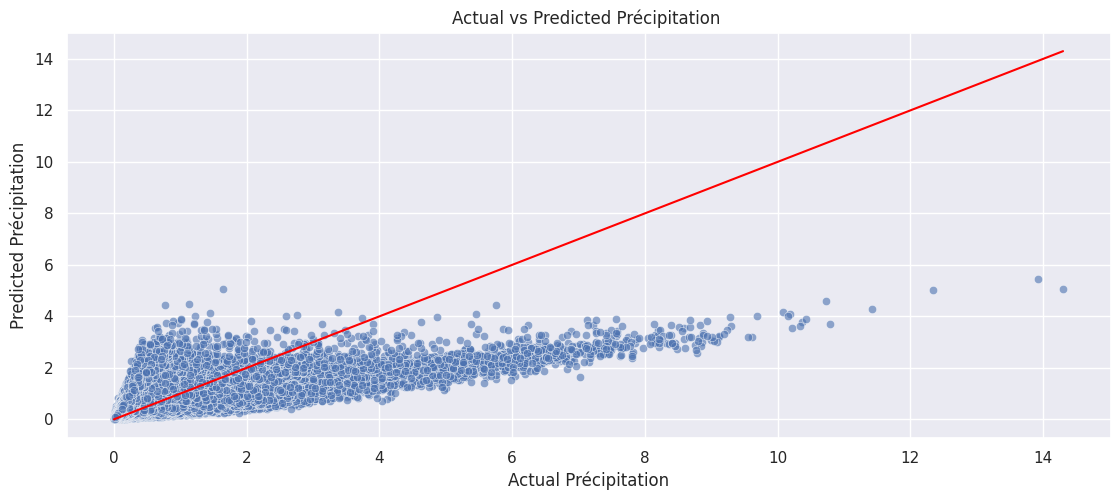

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
#plt.style.use('seaborn')
#plt.style.use("ggplot")
# Visualizing the regression results
plt.figure(figsize=(12,5))
sns.scatterplot(data=target_data, x=target_data['Total_precip'], y=target_data['Prediction'], alpha=0.6)
sns.lineplot(x=[target_data['Total_precip'].min(), 
               target_data['Total_precip'].max()], y=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], color='red')
plt.title('Actual vs Predicted Précipitation ')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

In [29]:
#!pip install seaborn

/tmp/ipykernel_6910/1039578056.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/scatterplot_validation.jpg', format='jpg', dpi=1000)
/home/oem/anaconda3/envs/climate-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


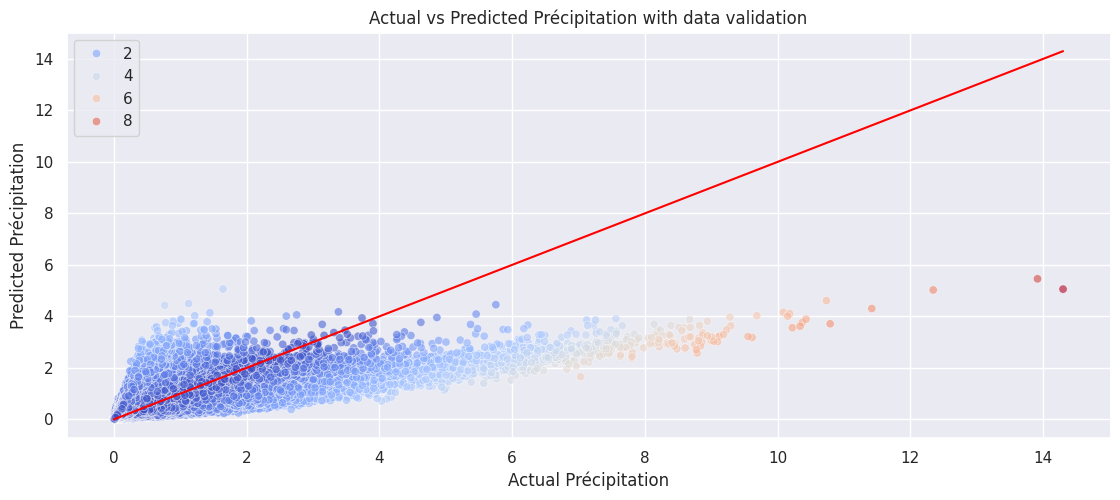

In [33]:
#plt.style.use('seaborn')
# Calculating the residuals (errors)
residuals = abs(target_data['Total_precip'] - target_data['Prediction'])

# Creating an enhanced scatter plot with residuals
plt.figure(figsize=(12,5))
scatter = sns.scatterplot(x=target_data['Total_precip'], y=target_data['Prediction'], hue=residuals, palette='coolwarm', alpha=0.6)
sns.lineplot(x=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], 
             y=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], color='red')

plt.title('Actual vs Predicted Précipitation with data validation')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.savefig('/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/scatterplot_validation.jpg', format='jpg', dpi=1000)
plt.legend()
plt.show()

In [34]:
y_true=pd.DataFrame(Y_val,columns =['Total_precip'], index=validate_synthetic.index)
Prediction=pd.DataFrame(Prediction,columns =['Prediction'], index=validate_synthetic.index)
target_data=pd.concat([y_true,Prediction], axis=1)
target_data

,Total_precip,Prediction
time,,
2020-06-15 23:34:45.955674112,0.240737,0.114311
2020-06-16 00:57:13.757999104,0.106789,0.054014
2020-06-16 01:38:27.659161600,0.046901,0.022672
2020-06-16 03:23:49.851021312,0.057856,0.026713
2020-06-16 03:39:51.923695616,0.031632,0.036297
...,...,...
2020-11-30 05:06:08.256278528,0.048088,0.144732
2020-11-30 05:19:52.889999360,0.051704,0.179759
2020-11-30 05:58:49.352208384,0.223948,0.911677


In [ ]:
# Suppression de la 2ème colonne "Prediction"
df = df.loc[:, ~df.columns.duplicated(keep='first')]


In [35]:
# Supprimer toutes les colonnes qui contiennent "_lag" dans leur nom
validate_synthetic = validate_synthetic.drop(
    columns=[col for col in validate_synthetic.columns if "_lag" in col]
)

print(validate_synthetic.columns)


Index(['longitude', 'latitude', 'Temp_2m', 'SST', 'level', 'Rel_hum',
       'Spec_hum', 'U_wind', 'V_wind', 'Total_precip', 'target'],
      dtype='object')


In [41]:
prediction_data=pd.concat([validate_synthetic,target_data], axis=1)
prediction_data

,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip,Prediction
time,,,,,,,,,,,,
2020-06-15 23:34:45.955674112,7.326290,8.643314,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311,0.240737,0.114311
2020-06-16 00:57:13.757999104,2.919444,10.189704,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014,0.106789,0.054014
2020-06-16 01:38:27.659161600,-1.232353,12.436743,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672,0.046901,0.022672
2020-06-16 03:23:49.851021312,7.610665,11.168816,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713,0.057856,0.026713
2020-06-16 03:39:51.923695616,-19.800112,16.910606,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297,0.031632,0.036297
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-30 05:06:08.256278528,4.228921,9.387922,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732,0.048088,0.144732
2020-11-30 05:19:52.889999360,-19.617558,16.425592,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759,0.051704,0.179759
2020-11-30 05:58:49.352208384,-19.789116,14.353416,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677,0.223948,0.911677


In [42]:
# Suppression de la 2ème colonne "Prediction"
prediction_data = prediction_data.loc[:, ~prediction_data.columns.duplicated(keep='first')]
prediction_data

,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip
time,,,,,,,,,,,
2020-06-15 23:34:45.955674112,7.326290,8.643314,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311,0.240737
2020-06-16 00:57:13.757999104,2.919444,10.189704,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014,0.106789
2020-06-16 01:38:27.659161600,-1.232353,12.436743,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672,0.046901
2020-06-16 03:23:49.851021312,7.610665,11.168816,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713,0.057856
2020-06-16 03:39:51.923695616,-19.800112,16.910606,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297,0.031632
...,...,...,...,...,...,...,...,...,...,...,...
2020-11-30 05:06:08.256278528,4.228921,9.387922,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732,0.048088
2020-11-30 05:19:52.889999360,-19.617558,16.425592,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759,0.051704
2020-11-30 05:58:49.352208384,-19.789116,14.353416,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677,0.223948


In [37]:
validate_synthetic = validate_synthetic.drop(columns=["Total_precip", "target"])
print(validate_synthetic.columns)


Index(['longitude', 'latitude', 'Temp_2m', 'SST', 'level', 'Rel_hum',
       'Spec_hum', 'U_wind', 'V_wind'],
      dtype='object')


In [38]:
validate_synthetic=pd.concat([validate_synthetic,Prediction], axis=1)
validate_synthetic

,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction
time,,,,,,,,,,
2020-06-15 23:34:45.955674112,0.910945,0.302673,0.286810,4.165923e-08,0.133528,0.203979,0.007282,0.365635,0.368572,0.114311
2020-06-16 00:57:13.757999104,0.763942,0.431728,0.466026,4.321319e-08,0.020571,0.520073,0.000943,0.156573,0.704223,0.054014
2020-06-16 01:38:27.659161600,0.625448,0.619255,0.659204,6.201011e-08,0.715577,0.650123,0.551064,0.230426,0.576380,0.022672
2020-06-16 03:23:49.851021312,0.920431,0.513440,0.547283,4.958069e-08,0.480396,0.588140,0.219104,0.169803,0.490522,0.026713
2020-06-16 03:39:51.923695616,0.006069,0.992624,0.626640,9.863648e-01,0.100538,0.770469,0.018874,0.474179,0.932172,0.036297
...,...,...,...,...,...,...,...,...,...,...
2020-11-30 05:06:08.256278528,0.807624,0.364815,0.355908,1.266320e-07,0.994454,0.660319,0.893853,0.428672,0.472801,0.144732
2020-11-30 05:19:52.889999360,0.012159,0.952147,0.463242,1.781976e-08,0.968857,0.503822,0.571450,0.598620,0.379789,0.179759
2020-11-30 05:58:49.352208384,0.006436,0.779212,0.366330,2.442689e-08,0.262412,0.488255,0.085906,0.607463,0.610525,0.911677


In [39]:
# 🔄 DÉNORMALISATION de toutes les colonnes normalisées
original_features = ['longitude', 'latitude', 'Temp_2m', 'SST','level',
                     'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']

X_scaled = validate_synthetic[original_features].values
X_denorm = scaler.inverse_transform(X_scaled)

# Remplacer toutes les colonnes par leurs valeurs dénormalisées
validate_synthetic[original_features] = X_denorm
validate_synthetic

,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction
time,,,,,,,,,,
2020-06-15 23:34:45.955674112,7.326290,8.643314,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311
2020-06-16 00:57:13.757999104,2.919444,10.189704,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014
2020-06-16 01:38:27.659161600,-1.232353,12.436743,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672
2020-06-16 03:23:49.851021312,7.610665,11.168816,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713
2020-06-16 03:39:51.923695616,-19.800112,16.910606,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297
...,...,...,...,...,...,...,...,...,...,...
2020-11-30 05:06:08.256278528,4.228921,9.387922,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732
2020-11-30 05:19:52.889999360,-19.617558,16.425592,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759
2020-11-30 05:58:49.352208384,-19.789116,14.353416,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677


In [43]:
# Enregistrement en CSV
prediction_data.to_csv("validate_synthetic.csv", index=True)

print("✅ Fichier sauvegardé : validate_synthetic.csv")


✅ Fichier sauvegardé : validate_synthetic.csv


In [44]:
prediction_data

,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Prediction,Total_precip
time,,,,,,,,,,,
2020-06-15 23:34:45.955674112,7.326290,8.643314,295.54570,0.000013,221.45150,32.052254,0.000146,-7.847553,-3.669004,0.114311,0.240737
2020-06-16 00:57:13.757999104,2.919444,10.189704,299.83463,0.000013,120.10258,73.223070,0.000021,-19.092920,7.343748,0.054014,0.106789
2020-06-16 01:38:27.659161600,-1.232353,12.436743,304.45767,0.000019,743.68940,90.161840,0.010897,-15.120418,3.149213,0.022672,0.046901
2020-06-16 03:23:49.851021312,7.610665,11.168816,301.77924,0.000015,532.67505,82.088690,0.004334,-18.381275,0.332186,0.026713,0.057856
2020-06-16 03:39:51.923695616,-19.800112,16.910606,303.67838,300.356800,191.85150,105.836754,0.000375,-2.009059,14.822785,0.036297,0.031632
...,...,...,...,...,...,...,...,...,...,...,...
2020-11-30 05:06:08.256278528,4.228921,9.387922,297.19934,0.000039,993.90894,91.489910,0.017674,-4.456836,-0.249225,0.144732,0.048088
2020-11-30 05:19:52.889999360,-19.617558,16.425592,299.76800,0.000006,970.94165,71.106390,0.011300,4.684550,-3.300973,0.179759,0.051704
2020-11-30 05:58:49.352208384,-19.789116,14.353416,297.44876,0.000008,337.09146,69.078830,0.001700,5.160214,4.269507,0.911677,0.223948
